# Visualizações - Campeonato Brasileiro

Gráficos construídos a partir da base tratada (`brasileirao_clean.csv`), gerada no notebook `EDA.ipynb`.

**Índice**
1. Configuração
2. Distribuição dos resultados
3. Clubes com mais vitórias
4. Média de gols por temporada
5. Público médio por temporada
6. Conclusões

## 1. Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Estilo padrão para todos os gráficos do projeto
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

# Paleta segura para daltonismo
AZUL = "#4C72B0"
LARANJA = "#DD8452"
CINZA = "#B0B0B0"

In [3]:
# Pasta onde os gráficos serão exportados
IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

df = pd.read_csv("../data/processed/brasileirao_clean.csv")
df["data"] = pd.to_datetime(df["data"])

df.shape

(8452, 40)

## 2. Distribuição dos resultados

Primeira pergunta: **existe vantagem em jogar em casa?**

In [4]:
contagem = df["resultado"].value_counts()
percentual = df["resultado"].value_counts(normalize=True) * 100

pd.DataFrame({"partidas": contagem, "percentual": percentual.round(1)})

,partidas,percentual
resultado,,
Mandante,4182,49.5
Empate,2248,26.6
Visitante,2022,23.9


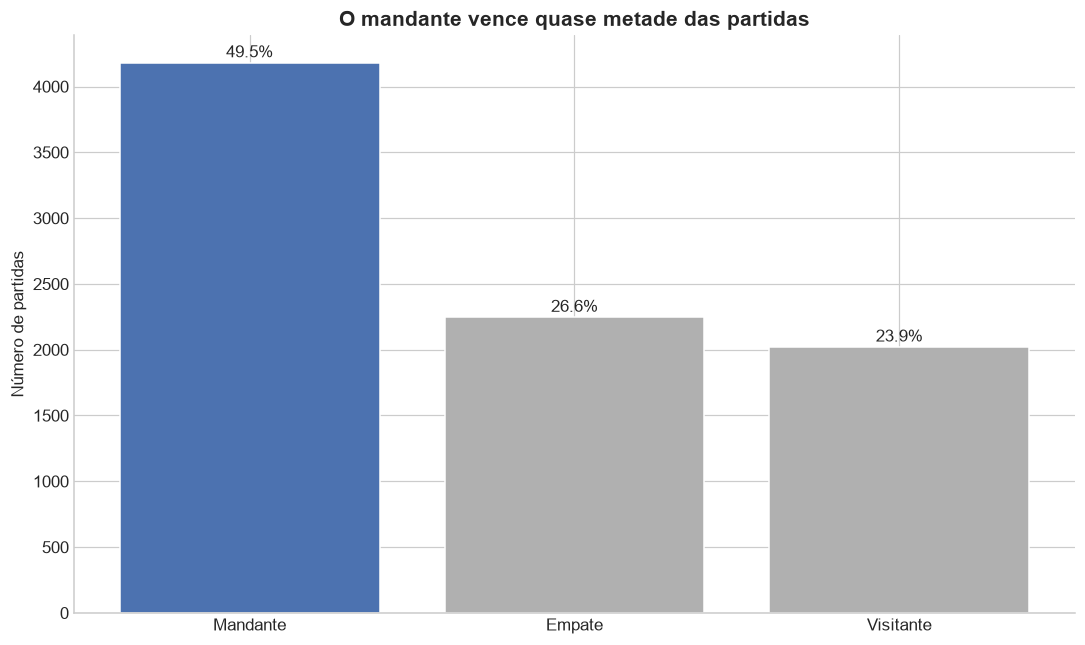

In [5]:
ordem = ["Mandante", "Empate", "Visitante"]
valores = df["resultado"].value_counts()[ordem]
percentuais = (valores / valores.sum() * 100)

fig, ax = plt.subplots()

# Destaque no mandante; as demais barras ficam em cinza
cores = [AZUL, CINZA, CINZA]
barras = ax.bar(ordem, valores.values, color=cores, edgecolor="white")

# Rótulo com o percentual em cima de cada barra
for barra, pct in zip(barras, percentuais):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 40,
        f"{pct:.1f}%",
        ha="center",
        fontsize=11,
    )

ax.set_title("O mandante vence quase metade das partidas")
ax.set_ylabel("Número de partidas")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMAGES / "distribuicao_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

A vantagem de jogar em casa é o efeito mais forte e consistente do futebol, e aparece com clareza na base.

## 3. Clubes com mais vitórias

A coluna `resultado` diz *quem* venceu apenas de forma posicional (mandante ou visitante). Para contar vitórias por clube é preciso cruzar essa informação com o nome do time.

In [6]:
vitorias_casa = df.loc[df["resultado"] == "Mandante", "time_mandante"]
vitorias_fora = df.loc[df["resultado"] == "Visitante", "time_visitante"]

vitorias = pd.concat([vitorias_casa, vitorias_fora]).value_counts()

top10 = vitorias.head(10)
top10

São Paulo        369
Flamengo         358
Palmeiras        339
Internacional    339
Atlético-MG      328
Fluminense       326
Corinthians      325
Grêmio           322
Cruzeiro         305
Santos FC        293
Name: count, dtype: int64

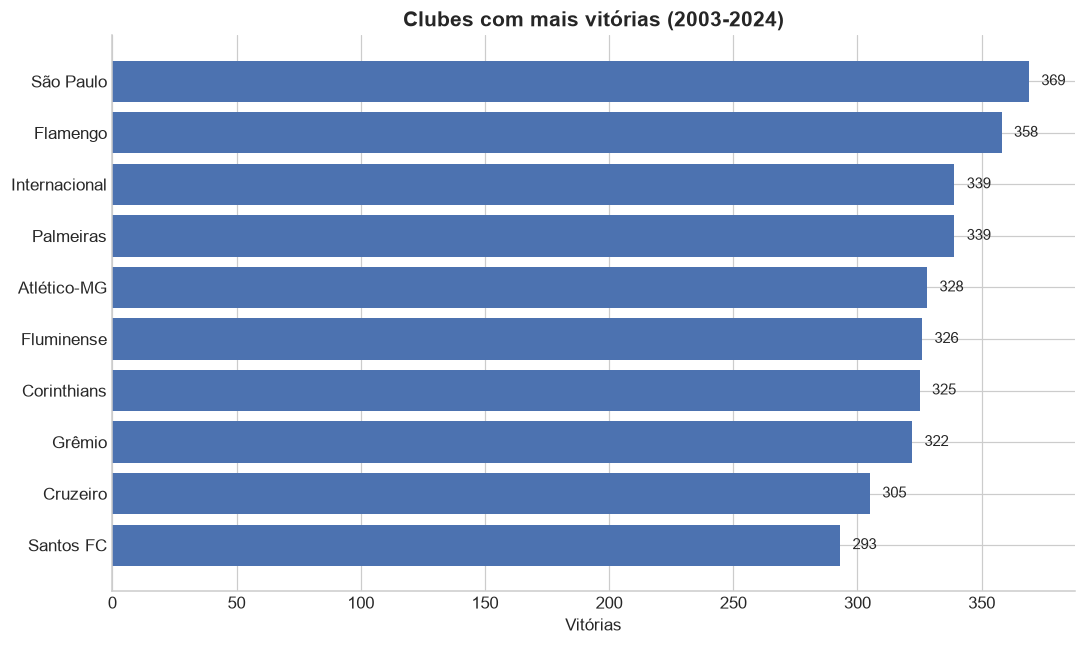

In [7]:
fig, ax = plt.subplots()

# Barras horizontais: nomes longos ficam legíveis sem rotacionar
dados = top10.sort_values()
barras = ax.barh(dados.index, dados.values, color=AZUL)

for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura + 5,
        barra.get_y() + barra.get_height() / 2,
        f"{largura:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
    )

ax.set_title("Clubes com mais vitórias (2003-2024)")
ax.set_xlabel("Vitórias")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMAGES / "top10_vitorias.png", dpi=150, bbox_inches="tight")
plt.show()

**Atenção à leitura deste gráfico.** O total de vitórias favorece clubes que disputaram todas as temporadas da Série A no período. Um time rebaixado por vários anos aparece pior do que realmente é, e a comparação não é justa.

O número de partidas disputadas por clube mostra a diferença:

In [8]:
jogos = pd.concat([df["time_mandante"], df["time_visitante"]]).value_counts()

comparacao = pd.DataFrame({
    "vitorias": vitorias,
    "jogos": jogos,
})
comparacao["aproveitamento_%"] = (comparacao["vitorias"] / comparacao["jogos"] * 100).round(1)

# Apenas clubes com presença relevante na Série A
comparacao[comparacao["jogos"] >= 200].sort_values("aproveitamento_%", ascending=False).head(10)

,vitorias,jogos,aproveitamento_%
Palmeiras,339,751,45.1
São Paulo,369,826,44.7
Flamengo,358,826,43.3
Internacional,339,787,43.1
Grêmio,322,751,42.9
Santos FC,293,684,42.8
Cruzeiro,305,713,42.8
Atlético-MG,328,786,41.7
Corinthians,325,788,41.2
Fluminense,326,827,39.4


O percentual de vitórias é uma métrica mais honesta para comparar clubes com históricos de participação diferentes.

## 4. Média de gols por temporada

In [9]:
gols_por_ano = df.groupby("ano_campeonato")["total_gols"].mean()
gols_por_ano.round(2)

ano_campeonato
2003    2.83
2004    2.76
2005    3.15
2006    2.71
2007    2.76
2008    2.72
2009    2.88
2010    2.57
2011    2.68
2012    2.47
2013    2.46
2014    2.26
2015    2.36
2016    2.41
2017    2.43
2018    2.18
2019    2.31
2020    2.48
2021    2.22
2022    2.38
2023    2.49
2024    2.44
Name: total_gols, dtype: float64

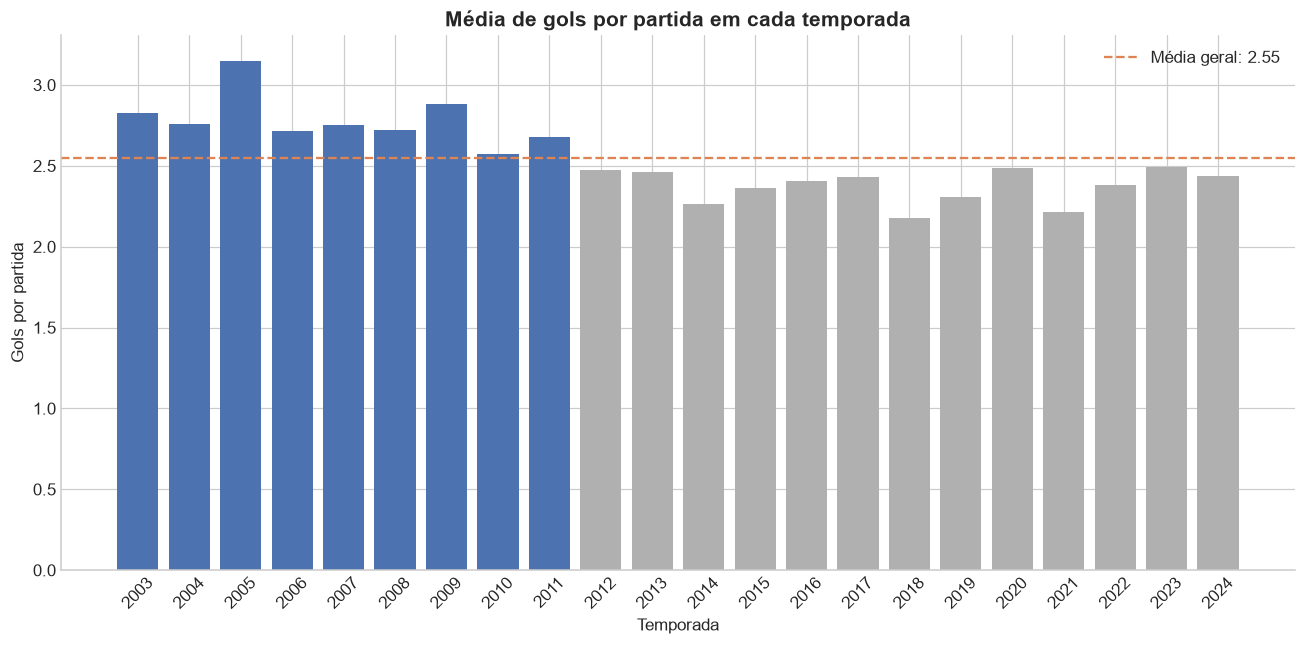

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

media_geral = df["total_gols"].mean()

# Destaca as temporadas acima da média geral
cores = [AZUL if v >= media_geral else CINZA for v in gols_por_ano.values]
ax.bar(gols_por_ano.index.astype(str), gols_por_ano.values, color=cores)

ax.axhline(
    media_geral,
    color=LARANJA,
    linestyle="--",
    linewidth=1.5,
    label=f"Média geral: {media_geral:.2f}",
)

ax.set_title("Média de gols por partida em cada temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("Gols por partida")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(IMAGES / "media_gols_temporada.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Público médio por temporada

In [11]:
publico_por_ano = df.groupby("ano_campeonato")["publico"].mean()

# Quantas partidas de cada temporada têm público registrado
registros = df.groupby("ano_campeonato")["publico"].count()
total = df.groupby("ano_campeonato")["publico"].size()

pd.DataFrame({
    "publico_medio": publico_por_ano.round(0),
    "partidas_com_registro": registros,
    "total_partidas": total,
})

,publico_medio,partidas_com_registro,total_partidas
ano_campeonato,,,
2003,NaN,0,456
2004,NaN,0,456
2005,NaN,0,418
2006,NaN,0,380
2007,17659.0,380,380
2008,7844.0,380,380
2009,17712.0,380,380
2010,14826.0,380,380
2011,14930.0,380,380


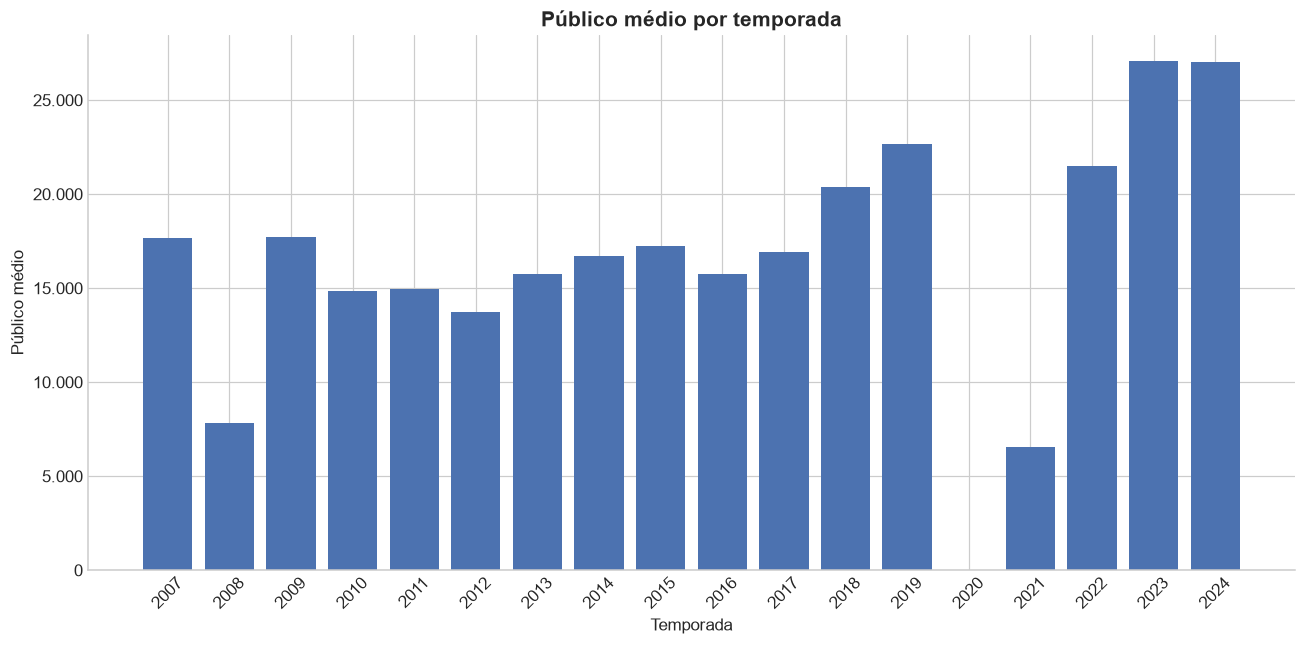

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

dados = publico_por_ano.dropna()
ax.bar(dados.index.astype(str), dados.values, color=AZUL)

ax.set_title("Público médio por temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("Público médio")
ax.spines[["top", "right"]].set_visible(False)

# Separador de milhar no eixo Y
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:,.0f}".replace(",", "."))
)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(IMAGES / "publico_medio_temporada.png", dpi=150, bbox_inches="tight")
plt.show()

**Duas ressalvas importantes na leitura:**

- As temporadas de 2003 a 2006 têm poucos registros de público, conforme identificado na EDA. As médias desses anos são calculadas sobre uma amostra pequena e não representam o período.
- As temporadas de 2020 e 2021 foram disputadas com restrição ou proibição de público em razão da pandemia de COVID-19. A queda nesses anos é um evento externo, não uma tendência do campeonato.

## 6. Conclusões

- **A vantagem de jogar em casa é evidente:** o mandante vence quase metade das partidas, enquanto o visitante vence bem menos.
- **Vitórias absolutas não comparam clubes de forma justa** — é preciso considerar o número de partidas disputadas. O aproveitamento percentual corrige essa distorção.
- **A média de gols por partida varia entre as temporadas**, permitindo investigar se houve mudança no perfil ofensivo do campeonato ao longo dos anos.
- **Os dados de público exigem cautela**, tanto pela ausência de registros nas primeiras temporadas quanto pelo efeito da pandemia em 2020 e 2021.

Os gráficos foram exportados para a pasta `images/`.

**Próximos passos:** histogramas e boxplots para analisar distribuições (Dia 9).